# O_99 – Daten-Provenienz & Werdegang
### CAS Information Engineering – Scripting Project (Dev/Helper)
**Gruppe:** SC26_Gruppe_2 | **Datum:** März–Mai 2026

---
Visualisiert die Daten-Pipeline anhand von `../sync/dataindex.csv`.  
**Manuell ausführen** — nicht Teil von `run_all.sh`.  
Voraussetzung: NB01–NB02 wurden bereits ausgeführt (../sync/dataindex.csv vorhanden).

---
[↑ Projektübersicht](O_01_Project_Overview.ipynb)


## Inhaltsverzeichnis<a id='toc_O_99'></a>

[Setup](#setup_O_99)  
1 [Daten laden und vorbereiten](#daten-laden-und-vorbereiten_O_99)  
2 [Chart A: Download-Zeitlinie](#chart-a-download-zeitlinie_O_99)  
3 [Chart B: Dateigrössenvergleich](#chart-b-dateigroessenvergleich_O_99)  
4 [Chart C: Datenpipeline-Flussdiagramm](#chart-c-datenpipeline-flussdiagramm_O_99)  
5 [Chart D: Versionshistorie & Fehleranalyse](#chart-d-versionshistorie-fehleranalyse_O_99)  
[Zusammenfassung](#zusammenfassung_O_99)  


---
## Setup <a id='setup_O_99'></a>

[↑ Inhaltsverzeichnis](#toc_O_99)


In [1]:
import os
import warnings
import pandas as pd
import numpy  as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates  as mdates
from   matplotlib.sankey import Sankey
from   datetime import datetime
warnings.filterwarnings('ignore')

import json as _json
with open('../sync/config.json', encoding='utf-8') as _cf: CFG = _json.load(_cf)
DATAINDEX  = '../sync/dataindex.csv'
SZ_AKTIV   = CFG['szenarien']['gleichzeitigkeit_aktiv']  # SSOT
CHARTS_DIR = os.path.join('output', 'charts', SZ_AKTIV)
os.makedirs(CHARTS_DIR, exist_ok=True)
DPI = CFG['visualisierung']['output_dpi']  # SSOT: ../sync/config.json
# ── Farben & Stil aus ../sync/config.json (SSOT) ─────────────────────────────────────
# Bestehende Variablen (Rückwärtskompatibilität)
_viz        = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK     = _viz.get('bg_dark',    '#0d1117')
BG_PANEL    = _viz.get('bg_panel',   '#141414')
C_PRICE     = _viz.get('c_price',    '#FFA726')
C_LOAD      = _viz.get('c_load',     '#66BB6A')
C_CHARGE    = _viz.get('c_charge',   '#1565C0')
C_FEED      = _viz.get('c_feed',     '#B71C1C')
SEG_COLORS  = _viz.get('seg_colors', ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350'])
C_PRIV, C_GEW, C_IND, C_UTIL = SEG_COLORS

# UI-Strukturfarben
C_ACHSE      = _viz.get('c_achse',      '#aaaaaa')  # Achsenbeschriftungen
C_TICK       = _viz.get('c_tick',       '#bbbbbb')  # Tick-Labels
C_SPINE      = _viz.get('c_spine',      '#333333')  # Achsenrahmen
C_LEGENDE_BG = _viz.get('c_legende_bg', '#111111')  # Legenden-Hintergrund
C_GITTER     = _viz.get('c_gitter',     '#cccccc')  # Gitterlinien

# Funktionale Extrafarben (nur laden was das NB braucht)
C_DISPATCH   = _viz.get('c_dispatch',   '#AB47BC')  # Dispatch-optimal
C_STACKING   = _viz.get('c_stacking',   '#5DCAA5')  # Revenue Stacking
C_SOLAR      = _viz.get('c_solar',      '#FDD835')  # Solar-Ertrag
C_GRENZWERT  = _viz.get('c_amber_dark', '#FF6F00')  # Grenzwert / Warnung
C_CYAN       = _viz.get('c_cyan',       '#26C6DA')  # Flusswasser / Alt. Speicher
C_GRUEN_DARK = _viz.get('c_gruen_dark', '#388E3C')  # Erneuerbare

# Stilkonstanten
_stil               = CFG.get('visualisierung', {}).get('stil', {})
LW                  = _stil.get('linienbreite_standard', 1.5)   # Standard-Linienbreite
LW_DUENN            = _stil.get('linienbreite_duenn',    0.8)   # dünne Linien
LW_DICK             = _stil.get('linienbreite_dick',     2.5)   # dicke Linien
ALPHA_FLAECHE       = _stil.get('alpha_flaeche',         0.12)  # dezente Füllung
ALPHA_FLAECHE_STARK = _stil.get('alpha_flaeche_stark',   0.35)  # Balken / Füllung
ALPHA_LEGENDE       = _stil.get('alpha_legende',         0.30)  # Legenden-BG
ALPHA_GEDAEMPFT     = _stil.get('alpha_linie_gedaempft', 0.55)  # Nebenlinien
FS_TITEL            = _stil.get('schriftgroesse_titel',   13)   # Chart-Titel
FS_ACHSE            = _stil.get('schriftgroesse_achse',   10)   # Achsenbeschr.
FS_TICK             = _stil.get('schriftgroesse_tick',     9)   # Ticks
FS_LEGENDE          = _stil.get('schriftgroesse_legende',  8)   # Legende
FS_KLEIN            = _stil.get('schriftgroesse_klein',    7)   # Annotationen

# matplotlib rcParams — nur stabile, versionsunabhängige Keys (matplotlib >= 3.5)
# axes.titlecolor (3.8+) und axes.grid (stört Karten) bewusst NICHT gesetzt
import matplotlib as _mpl
_mpl.rcParams.update({
    'figure.facecolor':  BG_DARK,
    'axes.facecolor':    BG_PANEL,
    'axes.edgecolor':    C_SPINE,
    'axes.labelcolor':   C_ACHSE,
    'axes.labelsize':    FS_ACHSE,
    'axes.titlesize':    FS_TITEL,
    'xtick.color':       C_TICK,
    'ytick.color':       C_TICK,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'text.color':        'white',
    'lines.linewidth':   LW,
    'legend.facecolor':  C_LEGENDE_BG,
    'legend.framealpha': ALPHA_LEGENDE,
    'legend.fontsize':   FS_LEGENDE,
    'legend.edgecolor':  C_SPINE,
})
print('Farben & Stil geladen.')

STATUS_COLORS = {
    'active'    : C_LOAD,  # grün
    'superseded': C_PRICE,  # orange
    'error'     : C_UTIL,  # rot
    'partial'   : C_PRIV,  # blau
}
TYPE_COLORS = {
    'raw'         : C_CHARGE,
    'processed'   : C_GRUEN_DARK,
    'intermediate': C_GRENZWERT,
    'raw/sim'     : '#546E7A',
    'intermediate/sim': '#78909C',
}
TYPE_LABELS = {
    'raw'         : 'Rohdaten (raw/)',
    'processed'   : 'Bereinigt (processed/)',
    'intermediate': 'Zwischenergebnisse (intermediate/)',
    'raw/sim'     : 'Simuliert (sim/raw/)',
    'intermediate/sim': 'Simuliert (sim/intermediate/)',
}

Farben & Stil geladen.


In [2]:
# Versionen anzeigen für Reproduzierbarkeit
print(f"Matplotlib   Version: {mpl.__version__}")
print(f"Numpy        Version: {np.__version__}")
print(f"Pandas       Version: {pd.__version__}")
print(f"📅 Zuletzt ausgeführt am: {datetime.now().strftime('%d.%m.%Y um %H:%M:%S')}")


Matplotlib   Version: 3.10.8
Numpy        Version: 2.2.6
Pandas       Version: 2.3.3
📅 Zuletzt ausgeführt am: 26.04.2026 um 18:53:45


**Setup.** Einheitliches dunkles Theme für alle Charts. `STATUS_COLORS` und `TYPE_COLORS`
kodieren den Zustand und die Verarbeitungsstufe jedes Eintrags konsistent über alle Visualisierungen.


---
## Daten laden und vorbereiten <a id='daten-laden-und-vorbereiten_O_99'></a>

[↑ Inhaltsverzeichnis](#toc_O_99)


In [3]:
# ── ../sync/dataindex.csv laden ──────────────────────────────────────────────────────
if not os.path.exists(DATAINDEX):
    raise FileNotFoundError(
        f'../sync/dataindex.csv nicht gefunden. NB1 und NB2 müssen zuerst ausgeführt werden.')

df = pd.read_csv(DATAINDEX)
df['timestamp']      = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
df['superseded_at']  = pd.to_datetime(df['superseded_at'], utc=True, errors='coerce')
df['size_kb']        = pd.to_numeric(df['size_kb'], errors='coerce')
df['rows']           = pd.to_numeric(df['rows'],    errors='coerce')

# Kurzname für Anzeige (ohne Extension)
df['label'] = df['filename'].str.replace(r'\.(csv|gpkg|json|xlsx)$', '', regex=True)

# Jüngster aktiver Eintrag pro Datei
df_active = df[df['status']=='active'].sort_values('timestamp')

print(f'Einträge gesamt   : {len(df)}')
print(f'Aktive Datensätze : {len(df_active)}')
print(f'Fehler            : {(df["status"]=="error").sum()}')
print(f'Superseded        : {(df["status"]=="superseded").sum()}')
print(f'\nZeitraum: {df["timestamp"].min().strftime("%Y-%m-%d %H:%M")} → '
      f'{df["timestamp"].max().strftime("%Y-%m-%d %H:%M")} UTC')
print()
print('Aktive Datensätze:')
for _, row in df_active.iterrows():
    size = f'{row["size_kb"]/1024:.1f} MB' if row['size_kb'] > 1024 else f'{row["size_kb"]:.0f} KB'
    rows_str = f'{int(row["rows"]):,} Zeilen' if pd.notna(row['rows']) else '—'
    print(f'  {row["filename"]:<35} [{row["data_type"]:<13}]  {size:>10}  {rows_str}')


Einträge gesamt   : 20
Aktive Datensätze : 16
Fehler            : 0
Superseded        : 4

Zeitraum: 2026-04-26 10:51 → 2026-04-26 14:25 UTC

Aktive Datensätze:
  ch_spot_prices_raw.csv              [raw          ]      946 KB  29,084 Zeilen
  ch_netzlast_raw.csv                 [raw          ]      962 KB  29,070 Zeilen
  ch_spot_prices_clean.csv            [processed    ]      1.2 MB  29,087 Zeilen
  wirtschaftlichkeit.csv              [intermediate ]        1 KB  4 Zeilen
  netzentlastung_szenarien.csv        [intermediate ]        0 KB  4 Zeilen
  spread_zeitreihe.csv                [intermediate ]        3 KB  41 Zeilen
  bfs_kantone.csv                     [intermediate ]        0 KB  26 Zeilen
  zonenbilanzen.csv                   [intermediate ]        1 KB  5 Zeilen
  rollout_spatial.csv                 [intermediate ]        2 KB  20 Zeilen
  zonenbilanzen_saisonal.csv          [intermediate ]        1 KB  20 Zeilen
  ch_crossborder_raw.csv              [raw          ]      6

In [4]:
# ── Verifikation: ../sync/dataindex.csv ─────────────────────────────────────────────
print(f'Einträge: {len(df)}')
print(f'Status  : {df["status"].value_counts().to_dict()}')
print(f'Typen   : {df["data_type"].value_counts().to_dict()}')
df[['filename','data_type','rows','size_kb','status']].head(5)


Einträge: 20
Status  : {'active': 16, 'superseded': 4}
Typen   : {'intermediate': 12, 'raw': 7, 'processed': 1}


,filename,data_type,rows,size_kb,status
0,ch_spot_prices_raw.csv,raw,29084,946.5,active
1,ch_netzlast_raw.csv,raw,29070,961.9,active
2,ch_spot_prices_clean.csv,processed,29087,1197.0,active
3,wirtschaftlichkeit.csv,intermediate,4,0.6,active
4,netzentlastung_szenarien.csv,intermediate,4,0.4,active


**Datenüberblick.** Der dataindex liest sich wie ein Logbuch: jeder Eintrag ist
eine Zeile mit Zeitstempel, Status und Metadaten. Aktive Einträge sind der aktuelle Stand,
superseded Einträge zeigen die Versionsgeschichte.


---
## Chart A: Download-Zeitlinie <a id='chart-a-download-zeitlinie_O_99'></a>

[↑ Inhaltsverzeichnis](#toc_O_99)


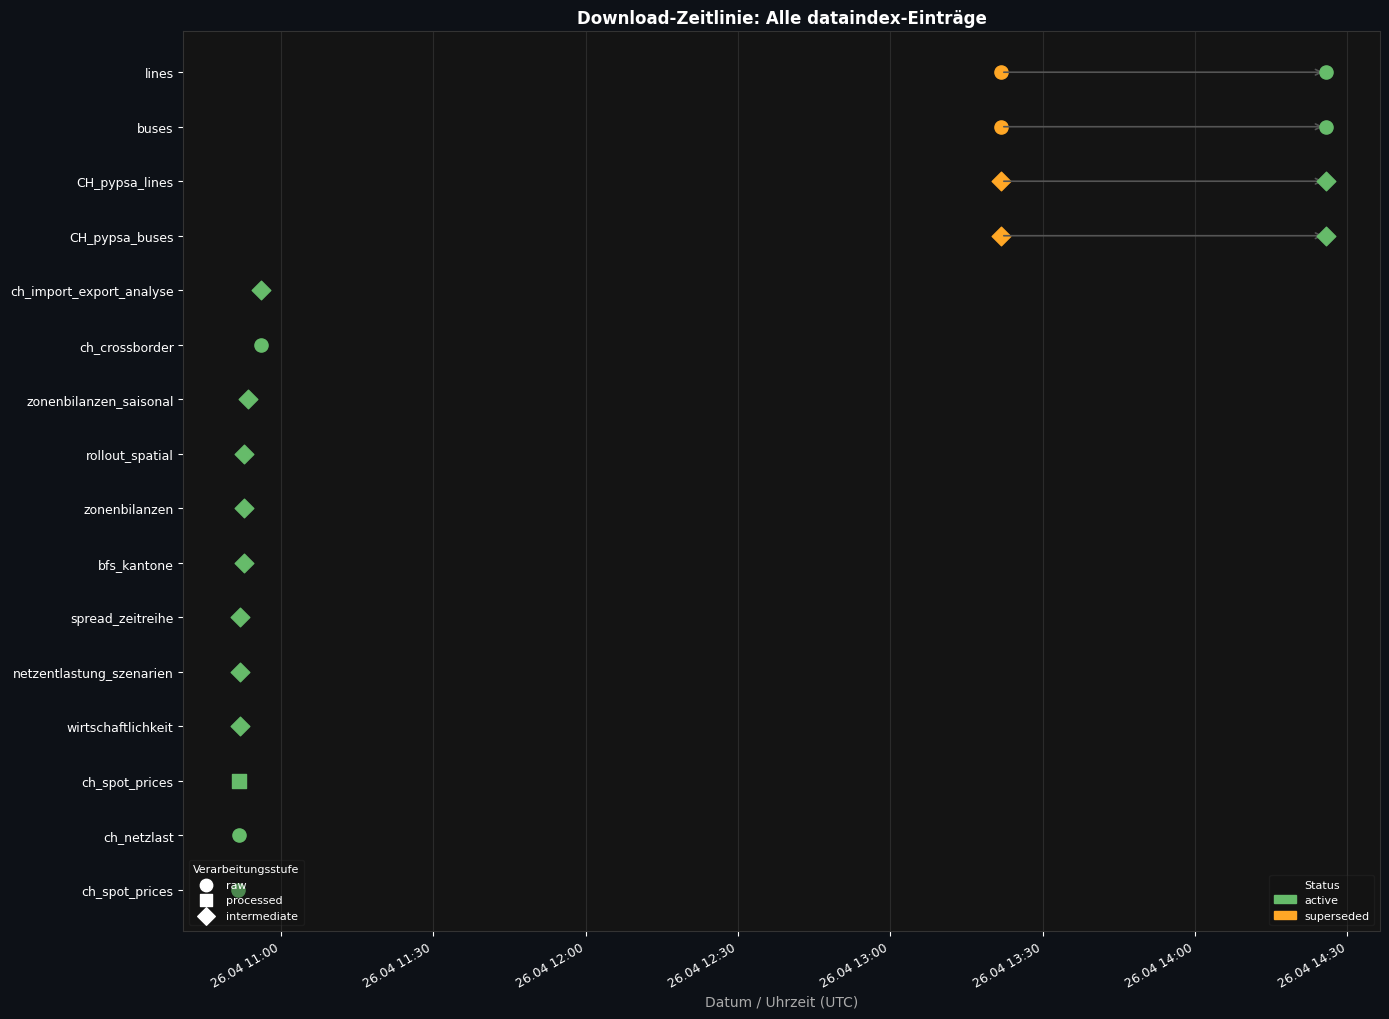

Chart A gespeichert: output\charts\realistisch\nb99_prov_zeitlinie.png


In [5]:
# ── Chart A: Zeitlinie aller Einträge ────────────────────────────────────────
# Jeder Eintrag als Punkt auf einem Zeitstrahl, gruppiert nach Datei
# Farbe = Status, Form = data_type

files_ordered = (df.sort_values('timestamp')
                   .groupby('filename')['timestamp'].min()
                   .sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(14, max(5, len(files_ordered)*0.55 + 1.5)))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

y_pos = {fname: i for i, fname in enumerate(files_ordered)}

for _, row in df.iterrows():
    y = y_pos[row['filename']]
    col = STATUS_COLORS.get(row['status'], '#888')
    dt_base = next((k for k in ['raw','processed','intermediate']
                    if str(row['data_type']).startswith(k)), 'other')
    marker = {'raw':'o','processed':'s','intermediate':'D','other':'P'}.get(dt_base,'P')
    ax.scatter(row['timestamp'], y, color=col, marker=marker, s=90, zorder=3)
    # Pfeil von superseded → nachfolger
    if row['status'] == 'superseded' and pd.notna(row['superseded_at']):
        ax.annotate('', xy=(row['superseded_at'], y), xytext=(row['timestamp'], y),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))

# Fehler-X gross
for _, row in df[df['status']=='error'].iterrows():
    ax.scatter(row['timestamp'], y_pos[row['filename']],
               color=C_UTIL, marker='x', s=160, linewidths=2.5, zorder=4)

ax.set_yticks(range(len(files_ordered)))
ax.set_yticklabels([f.replace('_raw','').replace('_clean','').replace('.csv','').replace('.gpkg','')
                    for f in files_ordered], fontsize=FS_TICK)
# X-Achse: AutoDateLocator passt Granularität automatisch an Datenzeitspanne an
# (MinuteLocator über ~11 Tage erzeugte >1000 Ticks → MAXTICKS-Fehler)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=FS_TICK)
ax.set_xlabel('Datum / Uhrzeit (UTC)', color=C_ACHSE)
ax.set_title('Download-Zeitlinie: Alle dataindex-Einträge', color='white', fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.15)

# Legende Status
status_handles = [mpatches.Patch(color=c, label=s) for s,c in STATUS_COLORS.items() if s in df['status'].values]
# Legende Typ
type_handles = [plt.scatter([],[],color='white',marker=m,s=80,label=t)
                for t,m in [('raw','o'),('processed','s'),('intermediate','D')]]
leg1 = ax.legend(handles=status_handles, title='Status', loc='lower right',
                 fontsize=FS_LEGENDE, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white',
                 title_fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=type_handles, title='Verarbeitungsstufe', loc='lower left',
          fontsize=FS_LEGENDE, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white', title_fontsize=8)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'nb99_prov_zeitlinie.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f'Chart A gespeichert: {p}')

**Chart A — Download-Zeitlinie.** Jeder Punkt ist ein dataindex-Eintrag. Die Pfeile
zwischen orangefarbenen (superseded) und grünen (active) Punkten zeigen Re-Downloads —
entweder nach Fehlern (rotes X → grüner Kreis) oder nach bewussten Aktualisierungen.
Die Form kodiert die Verarbeitungsstufe (Kreis = raw, Quadrat = processed, Diamant = intermediate).


---
## Chart B: Dateigrössenvergleich <a id='chart-b-dateigroessenvergleich_O_99'></a>

[↑ Inhaltsverzeichnis](#toc_O_99)


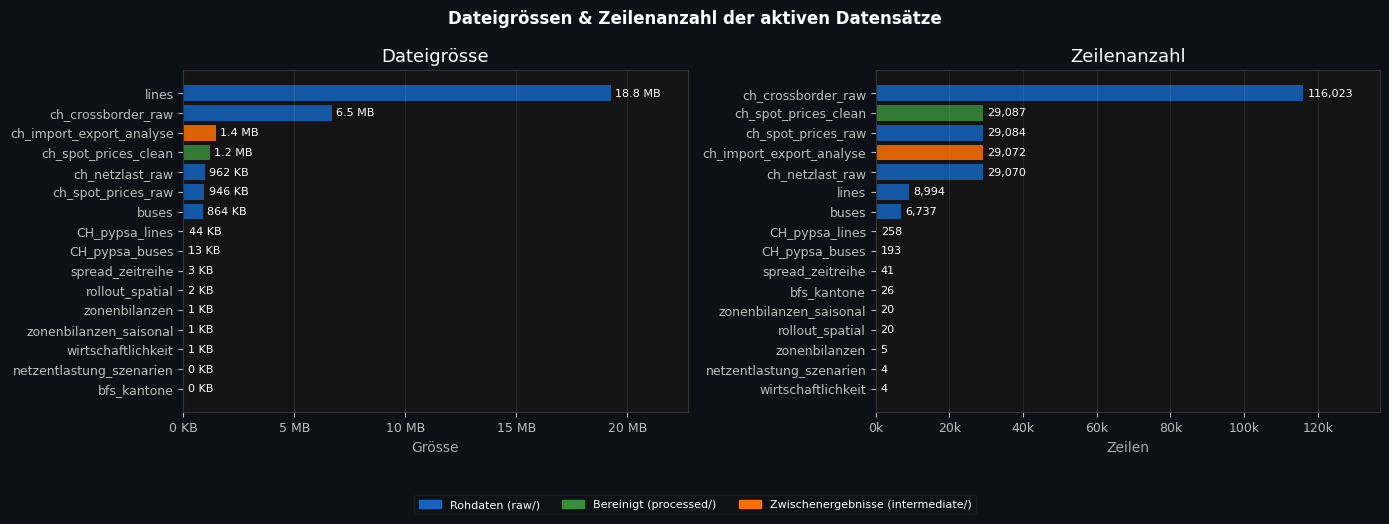

Chart B gespeichert: output\charts\realistisch\nb99_prov_dateigroessen.png


In [6]:
# ── Chart B: Grössenvergleich aktiver Dateien ────────────────────────────────
df_sz = df_active[df_active['size_kb'].notna()].copy()
df_sz = df_sz.sort_values('size_kb', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
    ax.tick_params(colors=C_TICK)
fig.suptitle('Dateigrössen & Zeilenanzahl der aktiven Datensätze', color='white', fontsize=12, fontweight='bold')

# Panel 1: Horizontale Balken — Grösse
ax = axes[0]
labels    = df_sz['label'].values
sizes_kb  = df_sz['size_kb'].values
bar_colors = [TYPE_COLORS.get(t, '#888') for t in df_sz['data_type']]

bars = ax.barh(labels, sizes_kb, color=bar_colors, alpha=0.85)
for bar, val in zip(bars, sizes_kb):
    unit = f'{val/1024:.1f} MB' if val > 1024 else f'{val:.0f} KB'
    ax.text(bar.get_width() + sizes_kb.max()*0.01, bar.get_y()+bar.get_height()/2,
            unit, va='center', color='white', fontsize=FS_LEGENDE)
ax.set_xlabel('Grösse', color=C_ACHSE)
ax.set_title('Dateigrösse', color='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v,_: f'{v/1024:.0f} MB' if v >= 1024 else f'{v:.0f} KB'))
ax.grid(True, axis='x', alpha=ALPHA_FLAECHE)
ax.set_xlim(0, sizes_kb.max() * 1.18)

# Panel 2: Zeilenanzahl (nur CSV)
df_rows = df_active[df_active['rows'].notna() & (df_active['data_type']!='raw/sim')].copy()
df_rows = df_rows.sort_values('rows')
row_colors = [TYPE_COLORS.get(t,'#888') for t in df_rows['data_type']]
bars2 = axes[1].barh(df_rows['label'], df_rows['rows'], color=row_colors, alpha=0.85)
for bar, val in zip(bars2, df_rows['rows']):
    axes[1].text(bar.get_width() + df_rows['rows'].max()*0.01,
                 bar.get_y()+bar.get_height()/2,
                 f'{int(val):,}', va='center', color='white', fontsize=FS_LEGENDE)
axes[1].set_xlabel('Zeilen', color=C_ACHSE)
axes[1].set_title('Zeilenanzahl', color='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}k'))
axes[1].grid(True, axis='x', alpha=ALPHA_FLAECHE)
axes[1].set_xlim(0, df_rows['rows'].max() * 1.18 if len(df_rows) else 1)

# Gemeinsame Legende
handles = [mpatches.Patch(color=TYPE_COLORS.get(t,'#888'), label=TYPE_LABELS.get(t,t))
           for t in df_active['data_type'].unique() if t in TYPE_COLORS]
fig.legend(handles=handles, loc='lower center', ncol=len(handles), fontsize=FS_LEGENDE,
           framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white', bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.06, 1, 1])
p = os.path.join(CHARTS_DIR, 'nb99_prov_dateigroessen.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f'Chart B gespeichert: {p}')

**Chart B — Dateigrössenvergleich.** Das [BFE](O_02_Glossar.ipynb#g-bfe) GeoPackage (blau, raw) dominiert mit **~56 MB📊**.
Die verarbeiteten Zeitreihen (grün, processed) sind grösser als die Rohdaten weil zusätzliche
Zeitfeature-Spalten hinzugefügt wurden. Zwischenergebnisse (orange, intermediate) sind
sehr klein — sie enthalten nur aggregierte Tabellen (4 Zeilen = 4 Segmente).


---
## Chart C: Datenpipeline-Flussdiagramm <a id='chart-c-datenpipeline-flussdiagramm_O_99'></a>

[↑ Inhaltsverzeichnis](#toc_O_99)


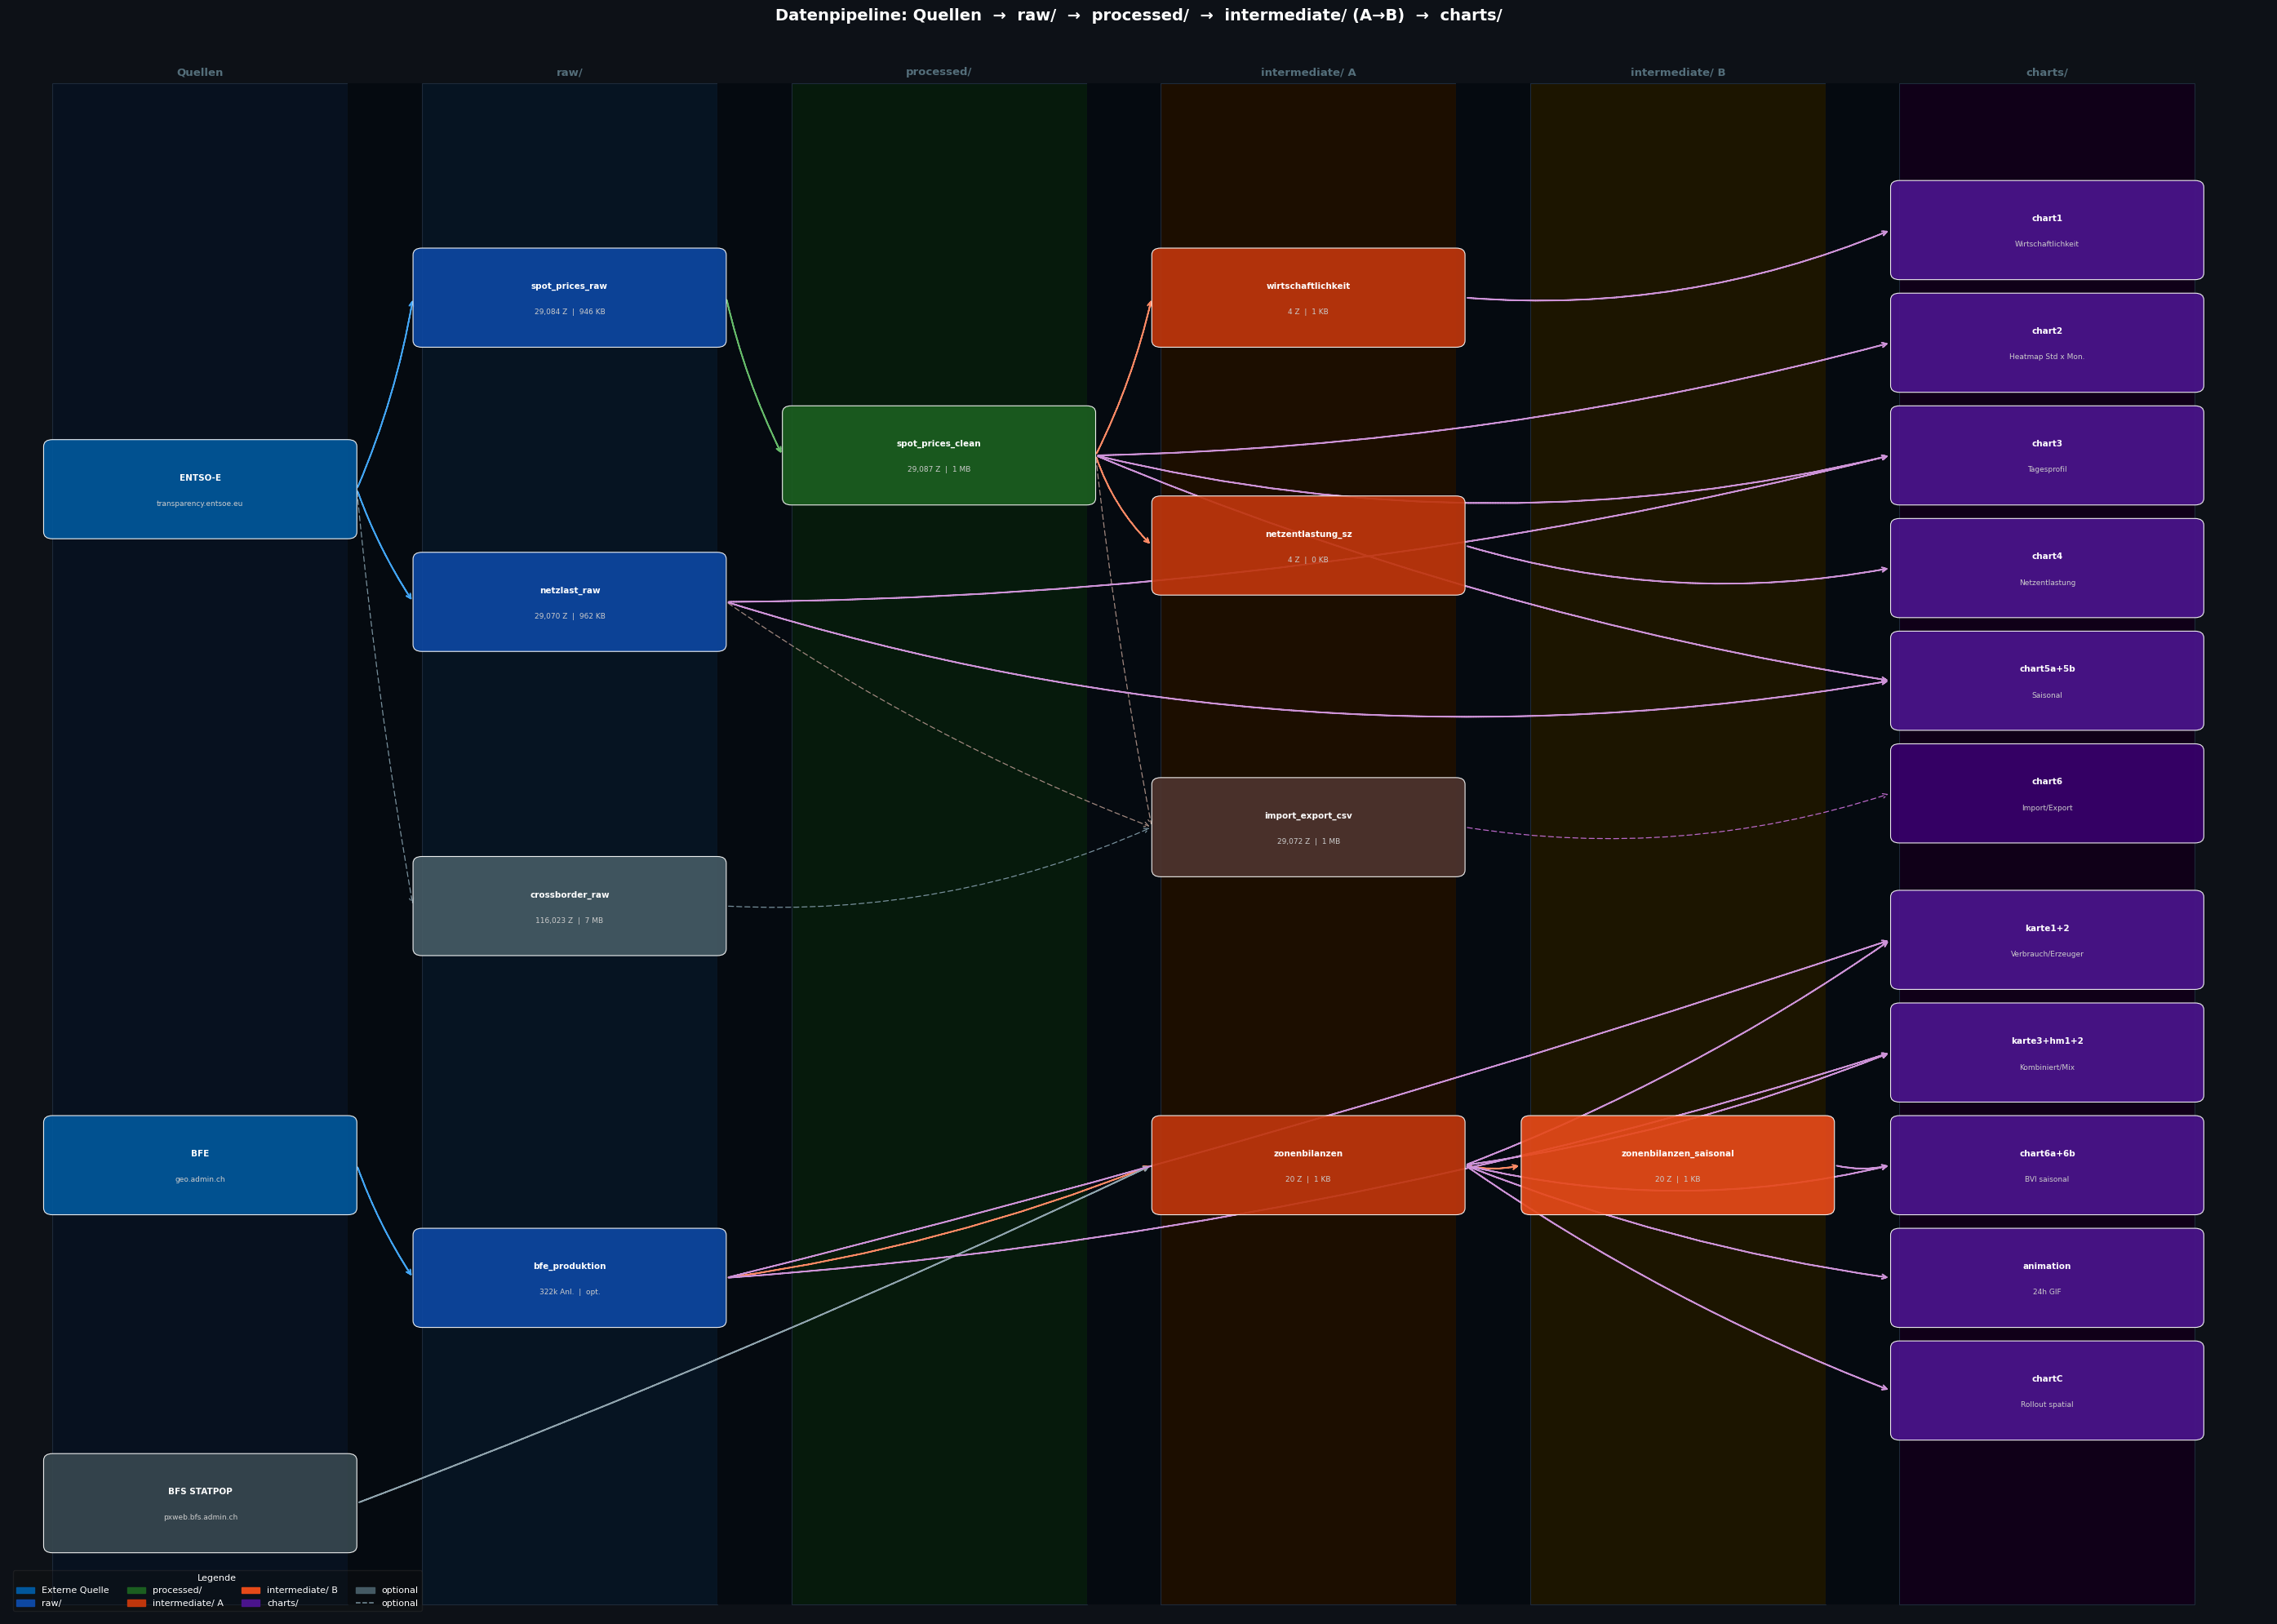

Chart C: output\charts\realistisch\nb99_prov_pipeline.png


In [7]:
# ── Chart C: Datenpipeline ───────────────────────────────────────────────────
from matplotlib.lines import Line2D

BW   = 1.00   # halbe Boxbreite
BH   = 0.38   # halbe Boxhoehe
SEP  = 0.50   # Trennspaltenbreite
CW   = 2.00   # Spaltenbreite (2×BW)

# Spalten-Mitten
XQ  =  1.0    # Quellen
XR  =  3.5    # raw/
XP  =  6.0    # processed/
XIA =  8.5    # intermediate/ A
XIB = 11.0    # intermediate/ B
XC  = 13.5    # charts/

# ── Dynamische Knotenstatistiken aus dataindex ───────────────────────────────
# Zeilenzahlen und Dateigrößen werden aus df_active gelesen, damit die Pipeline-
# Darstellung korrekt bleibt wenn neue ENTSO-E-Datenjahre nachgeladen werden.
def _nd(pattern, rows_fb=None, size_fb='opt.'):
    """Gibt 'X Z | Y KB/MB' aus df_active zurück; Fallback wenn Datei fehlt."""
    m = df_active[df_active['filename'].str.contains(pattern, na=False, case=False)]
    if m.empty:
        return f'{rows_fb}  |  {size_fb}' if rows_fb else size_fb
    row = m.sort_values('timestamp').iloc[-1]
    r = (f'{int(row["rows"]):,} Z' if pd.notna(row.get('rows')) and row.get('rows', 0) > 0
         else (rows_fb or '—'))
    kb = row.get('size_kb', None)
    s = (f'{kb/1024:.0f} MB' if pd.notna(kb) and kb >= 1024
         else f'{kb:.0f} KB' if pd.notna(kb)
         else size_fb)
    return f'{r}  |  {s}'

NODES = [
    ('src_entsoe', XQ, 13.5, 'ENTSO-E',          'transparency.entsoe.eu',          '#01579B'),
    ('src_bfe',    XQ,  7.5, 'BFE',              'geo.admin.ch',                    '#01579B'),
    ('src_bfs',    XQ,  4.5, 'BFS STATPOP',      'pxweb.bfs.admin.ch',              '#37474F'),
    ('raw_prices', XR, 15.2, 'spot_prices_raw',  _nd('spot_prices_raw'),            '#0D47A1'),
    ('raw_load',   XR, 12.5, 'netzlast_raw',     _nd('netzlast_raw'),               '#0D47A1'),
    ('raw_cross',  XR,  9.8, 'crossborder_raw',  _nd('crossborder', size_fb='opt.'),'#455A64'),
    ('raw_bfe',    XR,  6.5, 'bfe_produktion',   _nd('bfe', rows_fb='322k Anl.'),   '#0D47A1'),
    ('proc_clean', XP, 13.8, 'spot_prices_clean',_nd('spot_prices_clean'),          '#1B5E20'),
    ('int_econ',   XIA, 15.2, 'wirtschaftlichkeit', _nd('wirtschaftlichkeit', rows_fb='4 Z', size_fb='ROI/CAPEX'), '#BF360C'),
    ('int_sz',     XIA, 13.0, 'netzentlastung_sz',  _nd('netzentlastung',    rows_fb='4 Z', size_fb='Szenarien'),  '#BF360C'),
    ('int_ie',     XIA, 10.5, 'import_export_csv',  _nd('import_export',     size_fb='opt.'),                     '#4E342E'),
    ('int_zb',     XIA,  7.5, 'zonenbilanzen',       _nd('zonenbilanzen',     rows_fb='5 Z', size_fb='BVI'),       '#BF360C'),
    ('int_zbs',    XIB,  7.5, 'zonenbilanzen_saisonal', _nd('zonenbilanzen_saisonal', rows_fb='20 Z', size_fb='5x4'), '#E64A19'),
    ('ch1',  XC, 15.8, 'chart1',        'Wirtschaftlichkeit',   '#4A148C'),
    ('ch2',  XC, 14.8, 'chart2',        'Heatmap Std x Mon.',   '#4A148C'),
    ('ch3',  XC, 13.8, 'chart3',        'Tagesprofil',          '#4A148C'),
    ('ch4',  XC, 12.8, 'chart4',        'Netzentlastung',       '#4A148C'),
    ('ch5',  XC, 11.8, 'chart5a+5b',   'Saisonal',             '#4A148C'),
    ('ch6',  XC, 10.8, 'chart6',        'Import/Export',        '#38006B'),
    ('km12', XC,  9.5, 'karte1+2',     'Verbrauch/Erzeuger',   '#4A148C'),
    ('km3',  XC,  8.5, 'karte3+hm1+2', 'Kombiniert/Mix',       '#4A148C'),
    ('ch6b', XC,  7.5, 'chart6a+6b',   'BVI saisonal',         '#4A148C'),
    ('anim', XC,  6.5, 'animation',    '24h GIF',              '#4A148C'),
    ('chC',  XC,  5.5, 'chartC',       'Rollout spatial',      '#4A148C'),
]

EDGES = [
    ('src_entsoe','raw_prices',C_PRIV,False),
    ('src_entsoe','raw_load',  C_PRIV,False),
    ('src_entsoe','raw_cross', '#78909C',True),
    ('src_bfe',   'raw_bfe',   C_PRIV,False),
    ('raw_prices','proc_clean',C_LOAD,False),
    ('proc_clean','int_econ',  '#FF8A65',False),
    ('proc_clean','int_sz',    '#FF8A65',False),
    ('proc_clean','int_ie',    '#A1887F',True),
    ('raw_load',  'int_ie',    '#A1887F',True),
    ('raw_cross', 'int_ie',    '#78909C',True),
    ('raw_bfe',   'int_zb',    '#FF8A65',False),
    ('src_bfs',   'int_zb',    '#90A4AE',False),
    ('int_zb',    'int_zbs',   '#FF8A65',False),
    ('int_econ',  'ch1',  '#CE93D8',False),
    ('proc_clean','ch2',  '#CE93D8',False),
    ('proc_clean','ch3',  '#CE93D8',False),
    ('raw_load',  'ch3',  '#CE93D8',False),
    ('int_sz',    'ch4',  '#CE93D8',False),
    ('proc_clean','ch5',  '#CE93D8',False),
    ('raw_load',  'ch5',  '#CE93D8',False),
    ('int_ie',    'ch6',  '#BA68C8',True),
    ('raw_bfe',   'km12', '#CE93D8',False),
    ('int_zb',    'km12', '#CE93D8',False),
    ('raw_bfe',   'km3',  '#CE93D8',False),
    ('int_zb',    'km3',  '#CE93D8',False),
    ('int_zbs',   'ch6b', '#CE93D8',False),
    ('int_zb',    'ch6b', '#CE93D8',False),
    ('int_zb',    'anim', '#CE93D8',False),
    ('int_zb',    'chC',  '#CE93D8',False),
]

fig, ax = plt.subplots(figsize=(28, 20))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)
YMAX = 17.5
ax.set_xlim(-0.3, 15.0)
ax.set_ylim(3.5, YMAX)
ax.axis('off')
ax.set_title(
    'Datenpipeline: Quellen  \u2192  raw/  \u2192  processed/'
    '  \u2192  intermediate/ (A\u2192B)  \u2192  charts/',
    color='white', fontsize=14, fontweight='bold', pad=16)

node_pos = {n[0]: (n[1], n[2]) for n in NODES}

# Spalten-Hintergrundbänder (Inhaltspalten)
BANDS = [
    ( 0.0,  2.0, 'Quellen',          '#07111f'),
    ( 2.5,  4.5, 'raw/',             '#061422'),
    ( 5.0,  7.0, 'processed/',       '#061a0c'),
    ( 7.5,  9.5, 'intermediate/ A',  '#1c0e00'),
    (10.0, 12.0, 'intermediate/ B',  '#1c1500'),
    (12.5, 14.5, 'charts/',          '#100018'),
]
# Trennspalten (zwischen je zwei Inhaltsspalten)
SEPS = [2.0, 4.5, 7.0, 9.5, 12.0]  # linke Kante jeder Trennspalte

for x0, x1, label, bg in BANDS:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x0, 3.6), x1-x0, YMAX-4.0,
        boxstyle='square,pad=0', facecolor=bg,
        edgecolor='#1e2a3a', linewidth=LW_DUENN, zorder=0))
    ax.text((x0+x1)/2, YMAX-0.3, label,
            ha='center', va='center', color='#546E7A',
            fontsize=9.5, fontweight='bold')

# Trennspalten: etwas dunkler
for sx in SEPS:
    ax.add_patch(mpatches.FancyBboxPatch(
        (sx, 3.6), SEP, YMAX-4.0,
        boxstyle='square,pad=0', facecolor='#050a10',
        edgecolor='none', linewidth=0, zorder=0))

# Kanten
for src_id, dst_id, col, opt in EDGES:
    x1v, y1v = node_pos[src_id]
    x2v, y2v = node_pos[dst_id]
    lw   = 0.9 if opt else 1.4
    dash = (5, 3) if opt else (1, 0)
    dy   = abs(y1v - y2v)
    rad  = 0.12 if dy < 1.0 else (0.06 if dy < 3.0 else 0.02)
    ax.annotate('',
        xy=(x2v - BW - 0.06, y2v),
        xytext=(x1v + BW + 0.06, y1v),
        arrowprops=dict(
            arrowstyle='->', color=col, lw=lw,
            linestyle=(0, dash),
            connectionstyle=f'arc3,rad={rad}'),
        zorder=1)

# Knoten
for nid, x, y, line1, line2, color in NODES:
    box = mpatches.FancyBboxPatch(
        (x-BW, y-BH), 2*BW, 2*BH,
        boxstyle='round,pad=0.06',
        facecolor=color, edgecolor='white',
        linewidth=LW_DUENN, alpha=0.92, zorder=2)
    ax.add_patch(box)
    ax.text(x, y + (0.10 if line2 else 0), line1,
            ha='center', va='center', color='white',
            fontsize=7.5, fontweight='bold', zorder=3)
    if line2:
        ax.text(x, y - 0.13, line2,
                ha='center', va='center', color=C_GITTER,
                fontsize=6.5, zorder=3)

leg_items = [
    ('#01579B','Externe Quelle'),('#0D47A1','raw/'),
    ('#1B5E20','processed/'),    ('#BF360C','intermediate/ A'),
    ('#E64A19','intermediate/ B'),('#4A148C','charts/'),
    ('#455A64','optional'),
]
handles = [mpatches.Patch(color=c, label=l) for c,l in leg_items]
handles.append(Line2D([0],[0], color='#78909C', lw=1.1,
                      linestyle='--', label='optional'))
ax.legend(handles=handles, loc='lower left', fontsize=FS_LEGENDE,
          framealpha=0.4, facecolor=C_LEGENDE_BG, labelcolor='white',
          title='Legende', title_fontsize=8, ncol=4)

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'nb99_prov_pipeline.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f'Chart C: {p}')

**Chart C — Pipeline-Flussdiagramm.** Zeigt den vollständigen Datenfluss von den
externen Quellen (ENTSO-E, [BFE](O_02_Glossar.ipynb#g-bfe), BFS) bis zu den Visualisierungen. Die Dateigrössen
sind direkt aus dem dataindex annotiert. Dieses Diagramm aktualisiert sich automatisch
wenn neue Datensätze in den dataindex eingetragen werden.


---
## Chart D: Versionshistorie & Fehleranalyse <a id='chart-d-versionshistorie-fehleranalyse_O_99'></a>

[↑ Inhaltsverzeichnis](#toc_O_99)


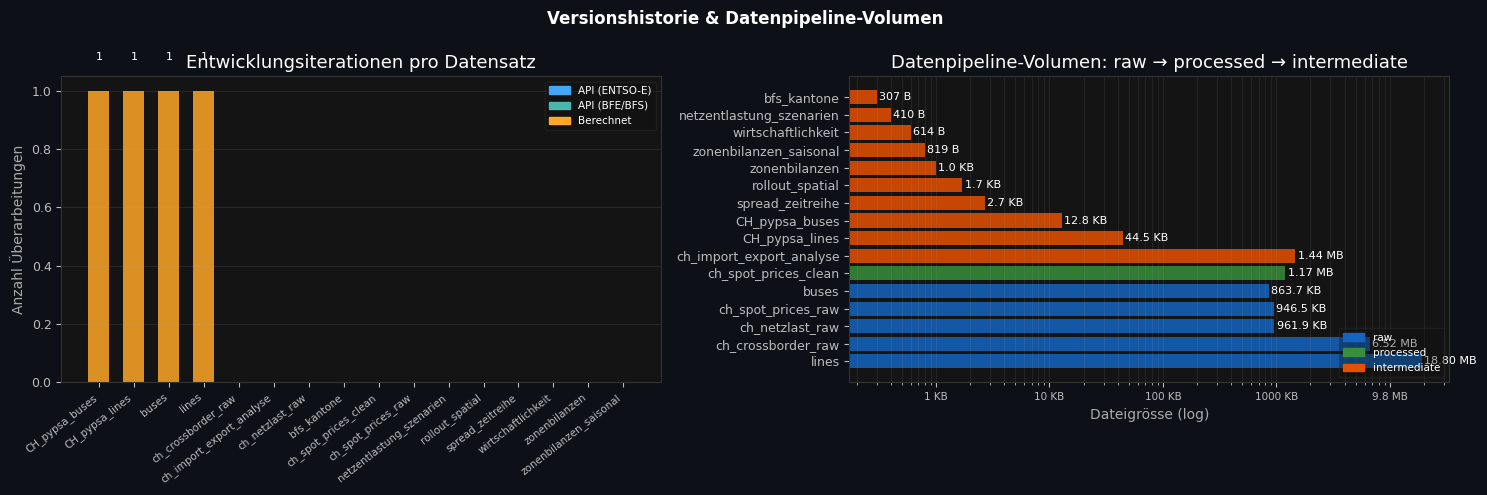

Chart D gespeichert: output\charts\realistisch\nb99_prov_versionshistorie.png


In [8]:
# ── Chart D: Versionshistorie & Datenpipeline-Volumen ────────────────────────
# Panel 1: Entwicklungsiterationen (superseded = wie oft neu berechnet/geladen)
# Panel 2: Dateigrösse nach Pipeline-Stufe — zeigt Datenvolumen und -transformation

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
    ax.tick_params(colors=C_TICK)
fig.suptitle('Versionshistorie & Datenpipeline-Volumen',
             color='white', fontsize=12, fontweight='bold')

# ── Panel 1: Iterationstiefe pro Datei ────────────────────────────────────────
# superseded = wie oft wurde diese Datei während der Entwicklung neu erzeugt
# → hoher Wert = viel Iteration (z.B. Parameter-Tuning, API-Retries)
ax = axes[0]
iter_data = []
for fname, grp in df.groupby('filename'):
    active    = grp[grp['status'] == 'active']
    superseded = (grp['status'] == 'superseded').sum()
    errors     = (grp['status'] == 'error').sum()
    dt = df_active[df_active['filename'] == fname]['data_type'].values
    dtype = dt[0] if len(dt) > 0 else 'unknown'
    # Herkunft klassifizieren
    src = active['source_url'].values[0] if not active.empty else ''
    if 'entsoe' in str(src).lower() or 'transparency' in str(src).lower():
        origin = 'API (ENTSO-E)'
    elif 'admin.ch' in str(src).lower() or 'bfe' in str(src).lower():
        origin = 'API (BFE/BFS)'
    elif 'pxweb' in str(src).lower() or 'bfs' in str(src).lower():
        origin = 'API (BFS)'
    elif 'SIM' in str(src).upper() or 'sim' in str(dtype):
        origin = 'Simuliert'
    else:
        origin = 'Berechnet'
    label = fname.replace('.csv','').replace('.gpkg','')[:24]
    iter_data.append({'label': label, 'superseded': superseded,
                      'errors': errors, 'origin': origin, 'dtype': dtype})

df_iter = pd.DataFrame(iter_data).sort_values('superseded', ascending=False)
origin_colors = {
    'API (ENTSO-E)': C_PRIV,
    'API (BFE/BFS)': '#4DB6AC',
    'API (BFS)':     C_CYAN,
    'Berechnet':     C_PRICE,
    'Simuliert':     '#78909C',
}
bar_c = [origin_colors.get(o, '#888') for o in df_iter['origin']]
xpos  = np.arange(len(df_iter))
bars  = ax.bar(xpos, df_iter['superseded'], 0.6, color=bar_c, alpha=0.85)
# Fehler-Overlay
err_vals = df_iter['errors'].values
if err_vals.sum() > 0:
    ax.bar(xpos, err_vals, 0.6, bottom=df_iter['superseded'].values,
           color=C_UTIL, alpha=0.75, label='Fehlerversuche')
for bar, val in zip(bars, df_iter['superseded']):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                str(int(val)), ha='center', va='bottom', color='white', fontsize=FS_LEGENDE)
ax.set_xticks(xpos)
ax.set_xticklabels(df_iter['label'], rotation=38, ha='right', fontsize=7.5)
ax.set_ylabel('Anzahl Überarbeitungen', color=C_ACHSE)
ax.set_title('Entwicklungsiterationen pro Datensatz', color='white')
ax.grid(True, axis='y', alpha=ALPHA_FLAECHE)
# Legende Herkunft
legend_handles = [mpatches.Patch(color=c, label=o)
                  for o, c in origin_colors.items() if o in df_iter['origin'].values]
if err_vals.sum() > 0:
    legend_handles.append(mpatches.Patch(color=C_UTIL, alpha=0.75, label='Fehlerversuche'))
ax.legend(handles=legend_handles, fontsize=7.5, framealpha=0.35,
          facecolor=C_LEGENDE_BG, labelcolor='white', loc='upper right')

# ── Panel 2: Dateigrösse nach Pipeline-Stufe (alle Dateien, log-Skala) ────────
ax = axes[1]

def fmt_size(kb):
    """Lesbare Grösse: Bytes → KB → MB, ohne führende Nullen."""
    if kb is None or (isinstance(kb, float) and kb != kb):
        return 'unbekannt'
    b = kb * 1024
    if b < 1024:
        return f'{b:.0f} B'
    elif kb < 1024:
        return f'{kb:.1f} KB'
    else:
        return f'{kb/1024:.2f} MB'

STAGE_ORDER = ['raw', 'raw/sim', 'processed', 'processed/sim',
               'intermediate', 'intermediate/sim']
STAGE_COLORS = {
    'raw':              C_CHARGE,
    'raw/sim':          '#546E7A',
    'processed':        C_GRUEN_DARK,
    'processed/sim':    '#558B2F',
    'intermediate':     '#E65100',
    'intermediate/sim': '#78909C',
    'unknown':          '#444444',
}

# Alle aktiven Dateien — auch ohne size_kb (Fallback: Datei lesen falls vorhanden)
size_rows = []
for _, row in df_active.iterrows():
    kb = row['size_kb']
    # Fallback: Grösse von Disk lesen wenn im dataindex fehlend
    if pd.isna(kb) and pd.notna(row.get('local_path', None)):
        try:
            import os as _os
            kb = _os.path.getsize(str(row['local_path'])) / 1024
        except Exception:
            kb = None
    dtype = row['data_type'] if pd.notna(row.get('data_type')) else 'unknown'
    label = row['filename'].replace('.csv','').replace('.gpkg','').replace('.json','')[:26]
    size_rows.append({'label': label, 'size_kb': kb, 'data_type': dtype,
                      'source_url': row.get('source_url','')})

size_data = pd.DataFrame(size_rows)
size_data['stage_order'] = size_data['data_type'].map(
    {s: i for i, s in enumerate(STAGE_ORDER)}).fillna(99)
# Dateien ohne Grösse: am Ende, mit Minimalwert für log-Skala
size_data['size_plot'] = size_data['size_kb'].fillna(0.1)
size_data = size_data.sort_values(['stage_order', 'size_plot'], ascending=[True, False])

bar_c2 = [STAGE_COLORS.get(t, STAGE_COLORS['unknown']) for t in size_data['data_type']]
bars2  = ax.barh(size_data['label'], size_data['size_plot'],
                 color=bar_c2, alpha=0.85)

for bar, (_, row) in zip(bars2, size_data.iterrows()):
    lbl = fmt_size(row['size_kb'])
    x_pos = max(bar.get_width() * 1.05, 0.15)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            lbl, va='center', color='white', fontsize=FS_LEGENDE)

# Log-Skala: sinnvoll wenn Dateigrössen > 3 Grössenordnungen auseinanderliegen
ax.set_xscale('log')
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda v, _: (f'{v*1024:.0f} B' if v < 1
                  else f'{v:.0f} KB' if v < 1024
                  else f'{v/1024:.1f} MB')))
ax.set_xlabel('Dateigrösse (log)', color=C_ACHSE)
ax.set_title('Datenpipeline-Volumen: raw → processed → intermediate', color='white')
ax.grid(True, axis='x', alpha=0.10, which='both')
ax.tick_params(axis='x', labelsize=7.5)

stage_handles = [mpatches.Patch(color=c, label=s)
                 for s, c in STAGE_COLORS.items()
                 if s in size_data['data_type'].values]
ax.legend(handles=stage_handles, fontsize=7.5, framealpha=0.35,
          facecolor=C_LEGENDE_BG, labelcolor='white', loc='lower right')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'nb99_prov_versionshistorie.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f'Chart D gespeichert: {p}')

**Chart D — Versionshistorie.** Links: wie viele Einträge (active, superseded, error)
existieren pro Datei — zeigt welche Datensätze mehrfach heruntergeladen wurden.
Rechts: die Zeitspanne zwischen dem ersten Versuch und dem ersten aktiven Stand.
Rote Balken markieren Dateien die vorher mindestens einmal fehlgeschlagen sind —
ein direktes Mass für die [API](O_02_Glossar.ipynb#g-api)-Zuverlässigkeit.


---
## Zusammenfassung <a id='zusammenfassung_O_99'></a>

[↑ Inhaltsverzeichnis](#toc_O_99)


In [9]:
# ── Zusammenfassung ──────────────────────────────────────────────────────────
print('=' * 60)
print('DATAINDEX ZUSAMMENFASSUNG')
print('=' * 60)
print(f'  Gesamt-Einträge   : {len(df)}')
print(f'  Aktive Datensätze : {len(df_active)}')
print(f'  Fehler            : {(df["status"]=="error").sum()} '
      f'({(df["status"]=="error").mean()*100:.0f}% aller Versuche)')
total_active_mb = df_active["size_kb"].sum() / 1024
print(f'  Gesamt Datengrösse: {total_active_mb:.1f} MB (aktive Datensätze)')

print()
print('  Pipeline-Verteilung (aktive Einträge):')
for dt, grp in df_active.groupby('data_type'):
    pct = len(grp)/len(df_active)*100
    bar = '█' * int(pct/5)
    print(f'  {TYPE_LABELS.get(dt,dt):<35} {bar} {len(grp)} Datei(en)')

print()
print(f'  Charts gespeichert unter {CHARTS_DIR}:')
for f in sorted(os.listdir(CHARTS_DIR)):
    if f.startswith('nb99_prov_'):
        kb = os.path.getsize(os.path.join(CHARTS_DIR, f))/1024
        print(f'  ✅ {f:<40} {kb:.0f} KB')

print()
print('NB6 abgeschlossen.')

DATAINDEX ZUSAMMENFASSUNG
  Gesamt-Einträge   : 20
  Aktive Datensätze : 16
  Fehler            : 0 (0% aller Versuche)
  Gesamt Datengrösse: 30.7 MB (aktive Datensätze)

  Pipeline-Verteilung (aktive Einträge):
  Zwischenergebnisse (intermediate/)  ████████████ 10 Datei(en)
  Bereinigt (processed/)              █ 1 Datei(en)
  Rohdaten (raw/)                     ██████ 5 Datei(en)

  Charts gespeichert unter output\charts\realistisch:
  ✅ nb99_prov_dateigroessen.png              139 KB
  ✅ nb99_prov_pipeline.png                   484 KB
  ✅ nb99_prov_versionshistorie.png           191 KB
  ✅ nb99_prov_zeitlinie.png                  103 KB

NB6 abgeschlossen.


**Zusammenfassung.** Alle vier Charts zeigen komplementäre Perspektiven auf denselben
dataindex. Das Notebook ist wartungsfrei: sobald ein Notebook neue Einträge schreiben,
werden alle Charts automatisch aktualisiert — ohne eine einzige Zeile Code zu ändern.


---
[↑ Projektübersicht](O_01_Project_Overview.ipynb)
